# EEG Data Analysis (Data Collection Experiments)

## Save All Event Markers

We want to save all the event markers from the data collection experiment along with their label and LSL time.

Loads the xdf file using pyxdf.

In [2]:
import pyxdf
import pandas as pd
import os

In [ ]:
# Config
n_experiment = 3
data_path = f'experiment_data/exp{n_experiment}/'
output_file_name = f'mentalab_markers_exp{n_experiment}.csv'
overwrite_existing = False

# Input: List of .xdf file paths
xdf_files = [
    data_path + f'exp{n_experiment}.xdf',
]

# Concatenate all markers from all files
all_markers = []

for file_path in xdf_files:
    data, _ = pyxdf.load_xdf(file_path)
    
    for stream in data:
        if stream['info']['name'][0] == 'Explore_84A1_Marker':
            time_series = stream['time_series']
            time_stamps = stream['time_stamps']
            
            for i, marker_row in enumerate(time_series):
                label = marker_row[0] if isinstance(marker_row, (list, tuple)) else marker_row
                all_markers.append({'label': label, 'lsl_time': time_stamps[i]})

# Create DataFrame and export to CSV
df = pd.DataFrame(all_markers)
output_path = data_path + output_file_name

if overwrite_existing:
    df.to_csv(output_path, index=False)
    print(f"Exported {len(df)} markers to {output_file_name}")
else:
    # Try incrementing suffix until we find an available filename
    if os.path.exists(output_path):
        base_name = output_file_name.rsplit('.', 1)[0]
        extension = output_file_name.rsplit('.', 1)[1] if '.' in output_file_name else 'csv'
        counter = 1
        while os.path.exists(output_path):
            new_filename = f"{base_name}_{counter}.{extension}"
            output_path = data_path + new_filename
            counter += 1
        df.to_csv(output_path, index=False)
        print(f"Exported {len(df)} markers to {os.path.basename(output_path)}")
    else:
        df.to_csv(output_path, index=False)
        print(f"Exported {len(df)} markers to {output_file_name}")

Exported 83 markers to mentalab_markers_exp3_1.csv


## Data Loading

Need access to data files: 
- `exp{n}.json`
- `all_markers_exp{n}.csv`

Place data files in directory: `/experiment_data/exp{n}/` and adjust "`n_experiment`" in the code.

In [1]:
## Imports
import numpy as np
import json
import pandas as pd

In [2]:
## Data Config
n_experiment = 3

data_dir = f'experiment_data/exp{n_experiment}/'
data_file = data_dir + f'exp{n_experiment}.json'

channel_mapping = {
    'CH1': 'Cz',
    'CH2': 'Pz',
    'CH3': 'T7',
    'CH4': 'T8',
    'CH5': 'P7',
    'CH6': 'P8',
    'CH7': 'O1',
    'CH8': 'O2'
}

### Load DataFrames from JSON Dicts

In [3]:
## Load JSON EEG/gaze dataset
def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

json_data = load_json(data_file)


In [4]:
def stream_to_dataframe(stream_data):
    """Convert a stream dict to a pandas DataFrame"""
    values = stream_data['Value']
    info = stream_data.get('Info', [])

    data_dict = {
        'TIMESTAMP': stream_data['TimeStamp'],
        'SAMPLING_RATE': stream_data['SamplingRate']
    }

    for i, name in enumerate(info):
        try:
            data_dict[name.upper()] = [value[i] for value in values]
        except (IndexError, TypeError):
            data_dict[name.upper()] = values

    return pd.DataFrame(data_dict)


In [5]:
## Set up DataFrames from data streams
# Create DataFrames from JSON dict data
gaze2D_df = stream_to_dataframe(json_data['Gaze2D'])
marker_df = stream_to_dataframe(json_data['Marker'])
eeg_df = stream_to_dataframe(json_data['EEG'])

# Apply EEG channel mapping to columns
eeg_df.rename(columns=channel_mapping, inplace=True)

# Zero EEG LSL timestamps to start at 0 (also use eeg_ts0 later for markers)
if 'TIMESTAMP' in eeg_df.columns:
    eeg_df['TIMESTAMP'] = eeg_df['TIMESTAMP'].astype(float)
    eeg_ts0 = float(eeg_df['TIMESTAMP'].min())
    eeg_df['TIMESTAMP'] = eeg_df['TIMESTAMP'] - eeg_ts0

print("\nEEG channels:")
print([c for c in eeg_df.columns if c not in ['TIMESTAMP','SAMPLING_RATE']][:10])
print(eeg_df.head())



EEG channels:
['Cz', 'Pz', 'T7', 'T8', 'P7', 'P8', 'O1', 'O2']
   TIMESTAMP  SAMPLING_RATE             Cz            Pz            T7  \
0   0.000000            251  104553.953125  79541.257812  77251.828125   
1   0.003989            251  104552.281250  79521.953125  77249.296875   
2   0.007977            251  104551.093750  79510.601562  77278.429688   
3   0.011966            251  104549.562500  79508.843750  77280.289062   
4   0.015955            251  104544.367188  79521.000000  77243.718750   

             T8            P7            P8            O1            O2  
0  88897.140625  83966.171875  82832.539062  70448.171875  96425.210938  
1  88906.578125  83965.929688  82834.210938  70421.179688  96413.773438  
2  88858.093750  83980.046875  82823.289062  70477.398438  96404.898438  
3  88867.578125  83981.906250  82814.750000  70525.851562  96397.078125  
4  88890.750000  83960.453125  82834.640625  70461.812500  96406.140625  


### Load Events from Final Manual Markers

Replace timestamps of events in the current markers dataframe with the finalized manual versions.

In [6]:
## Load event markers and use FINAL timestamps
events_df = pd.read_csv(data_dir + f'all_markers_exp{n_experiment}.csv')

events_df['TIMESTAMP'] = events_df['FINAL'].astype(float)

# Replace missing FINAL timestamps with MENTALAB timestamps
events_df['TIMESTAMP'] = events_df['TIMESTAMP'].fillna(events_df['MENTALAB'])

# Zero timestamps to match EEG zeroing
events_df['TIMESTAMP'] = events_df['TIMESTAMP'] - eeg_ts0

# Create 'id' column based on label naming convention
def extract_id(label):
    """Extract condition ID (Fam/Unf) from label format 'sw_{name}'"""
    if isinstance(label, str) and label.startswith('sw_'):
        name = label[3:]  # Remove 'sw_' prefix
        if name.startswith('F'):
            return 'Fam'
        elif name.startswith('U'):
            return 'Unf'
        elif name.startswith('M'):
            return 'Mov'
    return None

events_df['ID'] = events_df['LABEL'].apply(extract_id)

print(f"Loaded {len(events_df)} markers")
print("\nEvents:")
print(events_df.head())

Loaded 83 markers

Events:
      LABEL     MENTALAB        FINAL   TIMESTAMP   ID
0  sw_Move1  539964.3767          NaN   25.168899  Mov
1  sw_Move2  539974.1948          NaN   34.986999  Mov
2  sw_Move3  539983.6445          NaN   44.436699  Mov
3   sw_F1T1  540014.8629  540015.3801   76.172299  Fam
4     sw_U1  540046.2261  540046.6129  107.405099  Unf


## 

## EEG Preprocessing

Preprocess EEG to get the data to a usable state.
1. Filter Continuous EEG Data
2. Re-reference with CAR 
3. Epoch EEG data to Gaze-AOI Events
4. Subtract baseline mean from each epoch (baseline should be before movement)
5. Independent Component Analysis (ICA) to remove noise

#### Imports and Config

In [7]:
import mne
import numpy as np
import pandas as pd

In [8]:
# MNE/Jupyter plot setup
%matplotlib inline
# %matplotlib qt
# %gui qt
# mne.viz.set_3d_backend("notebook")
mne.viz.set_browser_backend("matplotlib")

Using matplotlib as 2D backend.


##### GPU Acceleration

For GPU acceleration, run in terminal:

```powershell
pip install cupy
MNE_USE_CUDA=true python -c "import mne; mne.cuda.init_cuda(verbose=True)"
```

In [9]:
# Enable CUDA in MNE
mne.utils.set_config('MNE_USE_CUDA', 'true')
# Verify CUDA is enabled
mne.cuda.init_cuda(verbose=True)

Now using CUDA device 0
Enabling CUDA with 5.00 GiB available memory
Enabling CUDA with 5.00 GiB available memory


#### EEG Data Preparation

In [10]:
print(eeg_df.head())

   TIMESTAMP  SAMPLING_RATE             Cz            Pz            T7  \
0   0.000000            251  104553.953125  79541.257812  77251.828125   
1   0.003989            251  104552.281250  79521.953125  77249.296875   
2   0.007977            251  104551.093750  79510.601562  77278.429688   
3   0.011966            251  104549.562500  79508.843750  77280.289062   
4   0.015955            251  104544.367188  79521.000000  77243.718750   

             T8            P7            P8            O1            O2  
0  88897.140625  83966.171875  82832.539062  70448.171875  96425.210938  
1  88906.578125  83965.929688  82834.210938  70421.179688  96413.773438  
2  88858.093750  83980.046875  82823.289062  70477.398438  96404.898438  
3  88867.578125  83981.906250  82814.750000  70525.851562  96397.078125  
4  88890.750000  83960.453125  82834.640625  70461.812500  96406.140625  


In [11]:
## Build MNE Raw Data with Channel Names
# Channel order:
# 1. Cz, 
# 2. Pz, 
# 3. T7, 
# 4. T8, 
# 5. P7, 
# 6. P8, 
# 7. O1, 
# 8. O2

# Channel label order for MNE
ch_names_desired = ["Cz", "Pz", "T7", "T8", "P7", "P8", "O1", "O2"]

# Current EEG columns
meta_cols = {"TIMESTAMP", "SAMPLING_RATE"}
eeg_cols_current = [c for c in eeg_df.columns if c not in meta_cols]

if len(eeg_cols_current) != len(ch_names_desired):
    print(
        f"Warning: expected {len(ch_names_desired)} EEG channels, found {len(eeg_cols_current)}: {eeg_cols_current}"
    )

# Prepare numeric data matrix (n_channels x n_times) for MNE RawArray
# Coerce to numeric and replace NaNs with 0 for stability
eeg_numeric = eeg_df[eeg_cols_current].apply(pd.to_numeric, errors='coerce')
data = eeg_numeric.to_numpy().T.astype(float, copy=False)
np.nan_to_num(data, copy=False)

# Convert from microvolts to volts (MNE expects volts)
data = data * 1e-6

# Sampling frequency
sfreq = float(eeg_df["SAMPLING_RATE"].iloc[0]) if "SAMPLING_RATE" in eeg_df.columns else None

# Create MNE Info and RawArray using our desired channel labels (truncate in case of mismatch)
ch_names = ch_names_desired[: data.shape[0]]
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info, verbose=True)

# Apply a standard montage that includes these channels
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False, on_missing='ignore')

print(raw)
print("Channels:", raw.ch_names)
print("Sampling rate:", raw.info['sfreq'])
print("Data range (V):", f"{data.min():.2e} to {data.max():.2e}")

Creating RawArray with float64 data, n_channels=8, n_times=469712
    Range : 0 ... 469711 =      0.000 ...  1871.359 secs
Ready.
    Range : 0 ... 469711 =      0.000 ...  1871.359 secs
Ready.
<RawArray | 8 x 469712 (1871.4 s), ~28.7 MiB, data loaded>
Channels: ['Cz', 'Pz', 'T7', 'T8', 'P7', 'P8', 'O1', 'O2']
Sampling rate: 251.0
Data range (V): -3.97e-01 to 2.11e-01


#### 1. Filter Continuous EEG Data

Apply a Butterworth Bandpass Filter (BPF)
- Low-pass of 40 Hz, high-pass of 1 Hz

Apply a Bandstop Filter (BPF) at power line noise frequency (60 Hz)

In [12]:
## Band-pass Filter EEG Data (1-40 Hz)
raw_filt = raw.copy().load_data()  # Use a copy

l_freq = 1.0  # Hz
h_freq = 40.0  # Hz

# Zero-phase FIR
a = raw_filt.filter(l_freq, h_freq)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 829 samples (3.303 s)

Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00

Effective window size : 8.159 (s)
Plotting power spectral density (dB=True).


c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\.venv_eeg\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


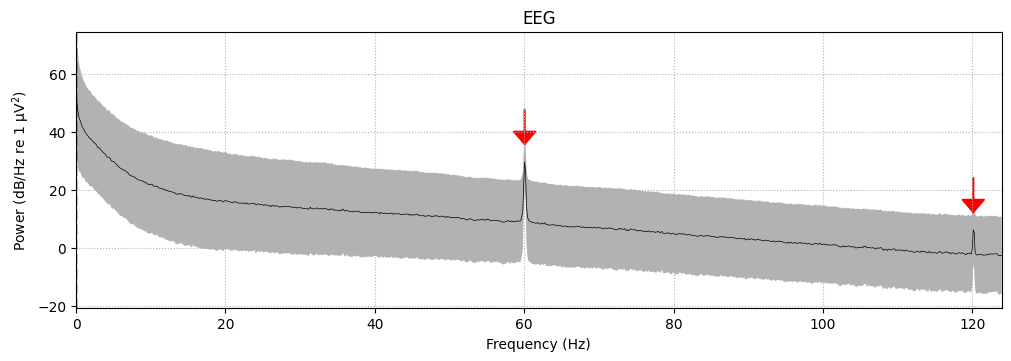

In [13]:
## View Spectrum to Identify Power Line Noise
# Function from MNE Python examples with modifications
def add_arrows(axes):
    """Add arrows at 60 Hz and its harmonics without indexing past data range."""
    harmonics = (60, 120, 180, 240)
    for ax in axes:
        # Choose the plotted line with the most points to derive freqs/psd safely
        lines = [ln for ln in ax.lines if hasattr(ln, "get_xdata")]
        if not lines:
            continue
        line = max(lines, key=lambda ln: len(ln.get_xdata()))
        freqs = np.asarray(line.get_xdata())
        psds = np.asarray(line.get_ydata())
        if freqs.size == 0 or psds.size == 0:
            continue

        fmax_plot = float(freqs[-1])
        for freq in harmonics:
            # Skip harmonics outside the plotted frequency range
            if freq > fmax_plot:
                continue
            # Find insertion index and clamp to valid range
            idx = int(np.searchsorted(freqs, freq, side="left"))
            if idx >= freqs.size:
                idx = freqs.size - 1
            if idx < 0:
                idx = 0

            # Robust neighborhood for peak arrow height
            i0 = max(0, idx - 4)
            i1 = min(psds.size, idx + 5)
            if i0 >= i1:
                y = float(psds[idx])
            else:
                y = float(psds[i0:i1].max())

            # Draw a short downward arrow
            ax.arrow(
                x=float(freqs[idx]),
                y=y + 18,
                dx=0,
                dy=-12,
                color="red",
                width=0.1,
                head_width=3,
                length_includes_head=True,
            )

# Plot PSD and annotate
fig = raw.compute_psd(fmax=124).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
)
add_arrows(fig.axes[:2])

In [14]:
## Notch filter at 60 and 120 Hz
freqs = [60.0, 120.0]
raw_filt.notch_filter(freqs=freqs)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1657 samples (6.602 s)



<RawArray | 8 x 469712 (1871.4 s), ~28.7 MiB, data loaded>

Filtered: <RawArray | 8 x 469712 (1871.4 s), ~28.7 MiB, data loaded>
Sampling rate: 251.0
Effective window size : 8.159 (s)


Plotting power spectral density (dB=True).


c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\.venv_eeg\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


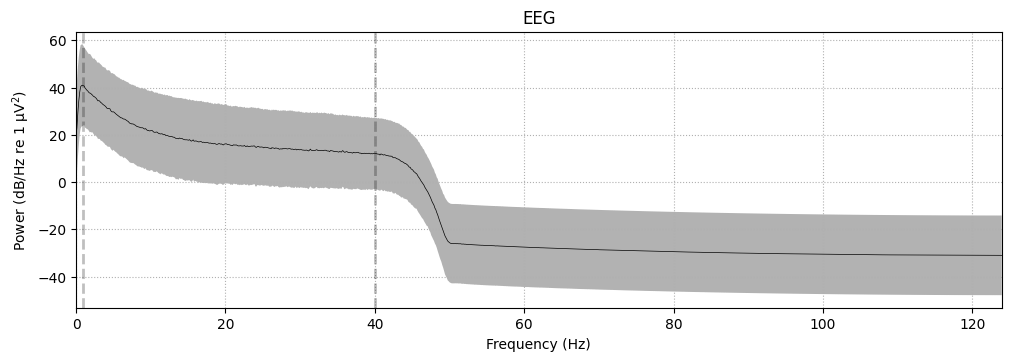

In [15]:
## Display Filtered Data Info and Plot PSD
print("Filtered:", raw_filt)
print("Sampling rate:", raw_filt.info['sfreq'])
fig = raw_filt.compute_psd(fmax=124).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
)

### 2. Re-reference with Common Average Reference (CAR)

Re-reference channels using common average reference (CAR).

Examines post-reference standard deviation of mean, which should be close to 0.

**Two CAR channels** should be **selected manually** - select the **lowest impedance midline electrode** (Pz or Cz - uses P300)  and the **lowest impedance parieto-occipital fusiform electrode** (T7/8, P7/8, O1/2 - uses N250).

In [16]:
## Common Average Reference (CAR)
avg_channels = ["CZ", "P8"]  # Select 2 best channels (low impedance midline & parieto-occipital)

ch_upper_map = {ch.upper(): ch for ch in raw_filt.ch_names}
picks_in_avg = [ch_upper_map[ch] for ch in avg_channels]

raw_filt, ref_data = mne.set_eeg_reference(raw_filt, ref_channels=picks_in_avg, projection=False)

# Sanity check
avg_std = float(raw_filt.get_data(picks=picks_in_avg).mean(axis=0).std())
print(f"Applied CAR with {len(avg_channels)} channels. Post-ref mean(trace) std: {avg_std * 1e6:.2f} μV")

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Applying a custom ('EEG',) reference.
Applied CAR with 2 channels. Post-ref mean(trace) std: 0.00 μV


### 3. Epoch EEG to Events

In [17]:
## Set up Events for MNE Epoching
epoch_dur = [-2, 2]
baseline = None

ts = eeg_df['TIMESTAMP'].to_numpy(dtype=float)

def nearest_indices(ts_array: np.ndarray, targets: np.ndarray) -> np.ndarray:
    idxs = []
    for t in targets:
        j = int(np.argmin(np.abs(ts_array - float(t))))
        idxs.append(j)
    return np.asarray(idxs, dtype=int)

# Filter for valid events with ID (Fam/Unf/Mov)
valid_events = events_df[events_df['ID'].isin(['Fam', 'Unf', 'Mov'])].dropna(subset=['TIMESTAMP', 'ID']).copy()

# Build event_id mapping
event_id = {'Fam': 1, 'Unf': 2, 'Mov': 3}

# Map ID to event codes
valid_events['event_code'] = valid_events['ID'].map(event_id)

# Convert timestamps to sample indices
sample_indices = nearest_indices(ts, valid_events['TIMESTAMP'].to_numpy())

# Build MNE events array
events_mne = np.column_stack([
    sample_indices,
    np.zeros(len(sample_indices), dtype=int),
    valid_events['event_code'].to_numpy()
])

# Sort by sample index
events_mne = events_mne[np.argsort(events_mne[:, 0])]

# Count events per condition
n_fam = int((valid_events['ID'] == 'Fam').sum())
n_unf = int((valid_events['ID'] == 'Unf').sum())
n_mov = int((valid_events['ID'] == 'Mov').sum())

print(f"Events: Fam={n_fam} | Unf={n_unf} | Mov={n_mov} | Total={len(events_mne)}")

Events: Fam=40 | Unf=40 | Mov=3 | Total=83


In [18]:
## Create Epochs at finalized marker events
## Rejection criteria for epochs
reject_criteria = dict(eeg=5e-3)  # 5000 µV threshold for EEG channels
flat_criteria = dict(eeg=1e-6)      # 1 µV flat signal threshold

print(f"Rejection criteria: {reject_criteria}")
print(f"Flat signal criteria: {flat_criteria}")

epochs = mne.Epochs(
    raw_filt,
    events=events_mne,
    event_id=event_id,
    picks=['Cz','Pz','T7','T8','P7','P8','O2'],
    tmin=epoch_dur[0],
    tmax=epoch_dur[1],
    baseline=None, # no baseline correction yet
    preload=True,
    reject=None,
    flat=None
)
print(epochs)

Rejection criteria: {'eeg': 0.005}
Flat signal criteria: {'eeg': 1e-06}
Not setting metadata
83 matching events found
83 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 83 events and 1005 original time points ...
0 bad epochs dropped
<Epochs | 83 events (all good), -2 – 2 s (baseline off), ~4.5 MiB, data loaded,
 'Fam': 40
 'Unf': 40
 'Mov': 3>


Plotting epochs...


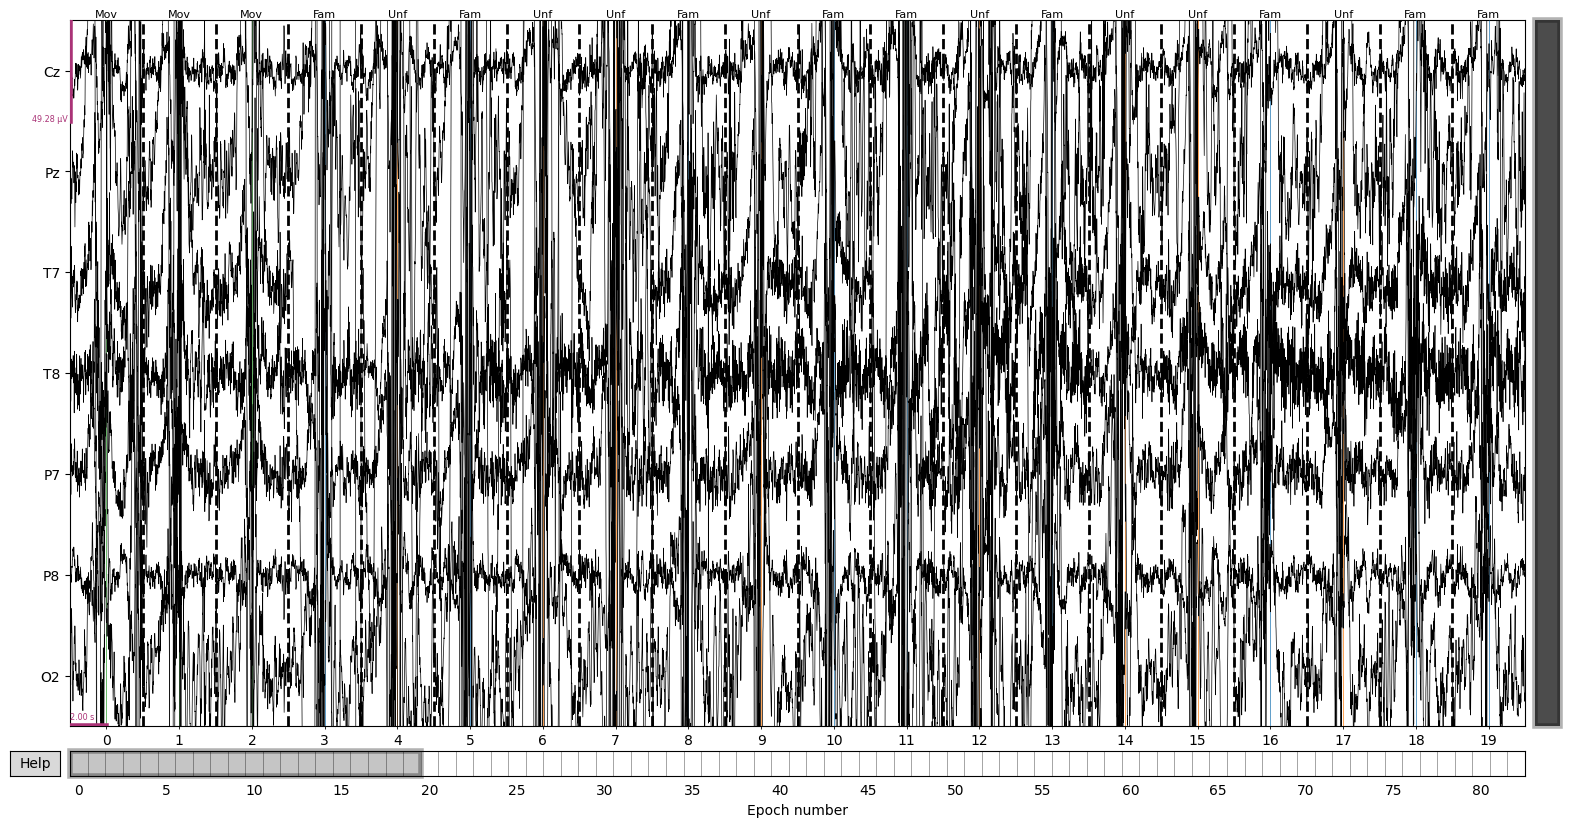

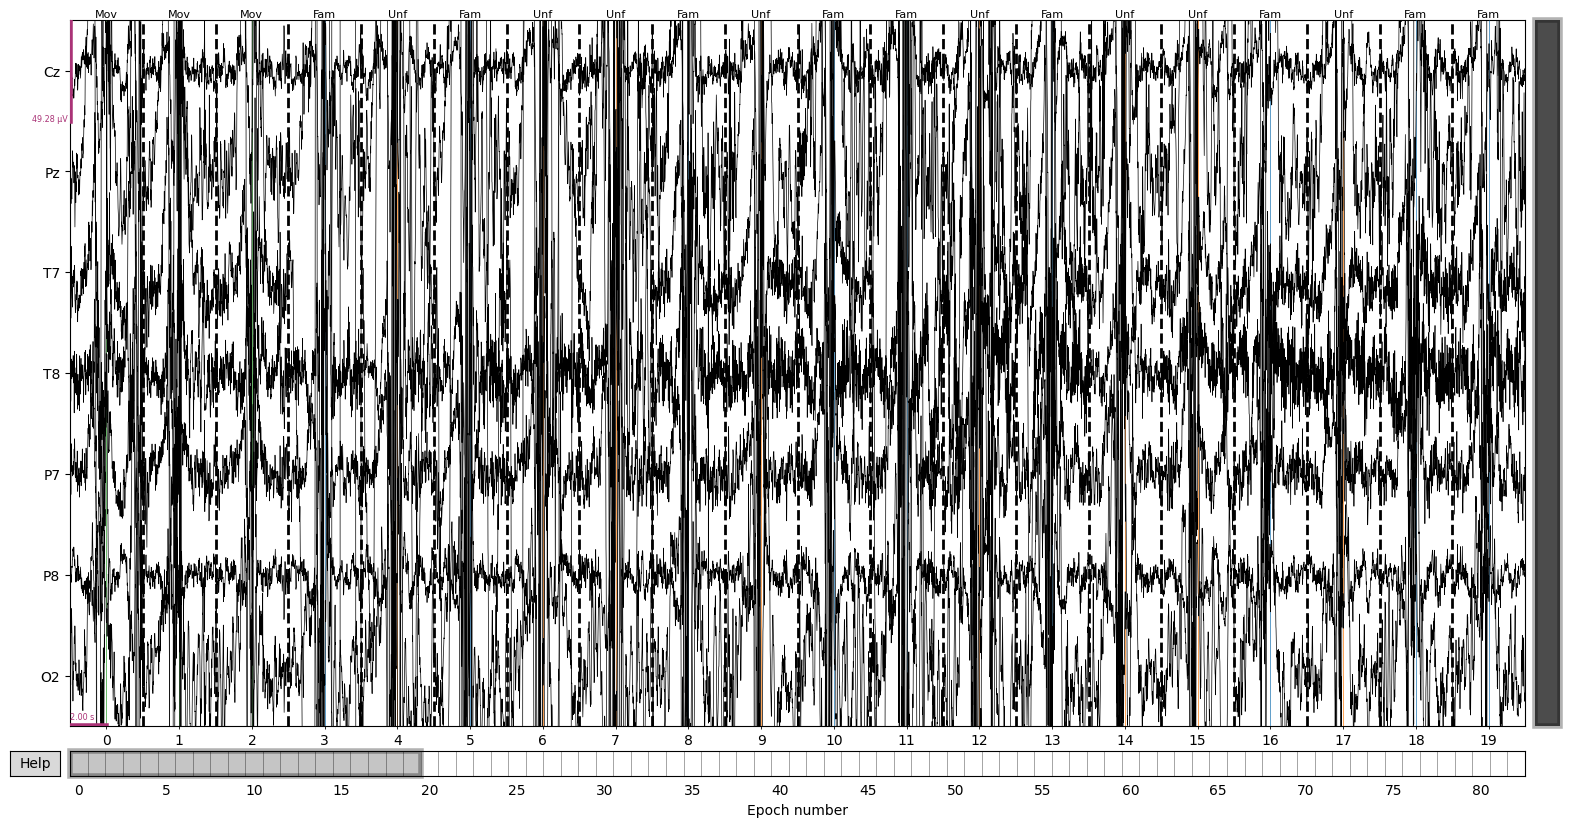

In [19]:
## Plot Epochs
print("Plotting epochs...")
epochs.plot(scalings='auto', event_id=True, events=True)

In [21]:
## Save epoched EEG data to file
filename = data_dir + f"eeg_exp{n_experiment}_epochs_1_reref-epo.fif"
epochs.save(filename, overwrite=True)
print(f"Saved: {filename}")

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Saved: experiment_data/exp3/eeg_exp3_epochs_1_reref-epo.fif


### 4. Subtract baseline mean from each epoch

Set baseline for correction BEFORE movement occurs (e.g. head movement, eye movement, eye-opening)

##### Investigate Baseline

In [22]:
## Load epoched EEG data from file
filename = data_dir + f"eeg_exp{n_experiment}_epochs_1-epo.fif"
epochs = mne.read_epochs(filename, preload=True)

Reading c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\experiment_data\exp3\eeg_exp3_epochs_1-epo.fif ...
    Found the data of interest:
    Found the data of interest:
        t =   -2000.00 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
83 matching events found
No baseline correction applied
0 projection items activated


More than 6 channels, truncating title ...
Not setting metadata
83 matching events found
No baseline correction applied
0 projection items activated
combining channels using "median"


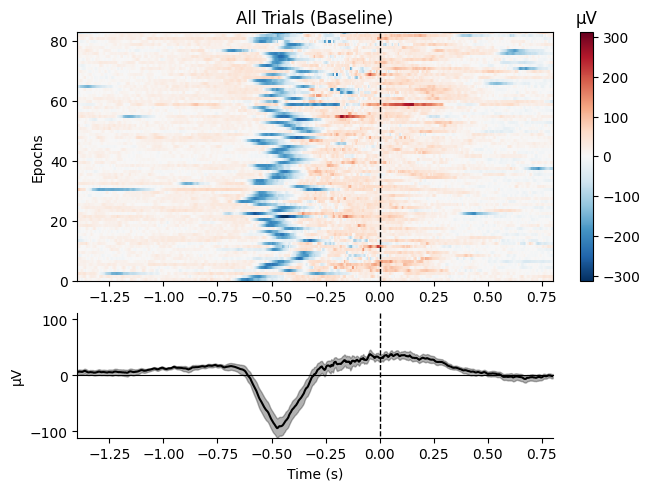

[<Figure size 640x480 with 3 Axes>]

In [24]:
## Check all trials to find movement noise duration
# Crop epochs to desired time range first
epochs_cropped = epochs.copy().crop(tmin=-1.4, tmax=0.8)
epochs_cropped.plot_image(picks=['Cz','Pz','T7','T8','P7','P8','O2'], combine='median', sigma=0, title='All Trials (Baseline)')

**Results**
- Movement range from `-0.65` to `0.1` s.
- Baseline before `-0.7`s

##### Reject Bad Trials (from outside movement range)

In [36]:
## Load epoched EEG data from file
filename = data_dir + f"eeg_exp{n_experiment}_epochs_1_reref-epo.fif"
epochs = mne.read_epochs(filename, preload=True)

Reading c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\experiment_data\exp3\eeg_exp3_epochs_1_reref-epo.fif ...
    Found the data of interest:
        t =   -2000.00 ...    2000.00 ms
        0 CTF compensation matrices available
    Found the data of interest:
        t =   -2000.00 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
83 matching events found
No baseline correction applied
0 projection items activated


Rejection summary (threshold: 500 µV):
- Bad in baseline window [-1, -0.65]: 0
- Bad in ERP window [0.1, 0.65]: 4
- Total to drop: 4 of 83
- Ignored channels (excluded from decision): T7, Pz

Detail of offending channels per rejected epoch:
Epoch 7: label=Unf, movement=unf
  - Baseline [-1, -0.65] bad channels (0): None
  - ERP [0.1, 0.65] bad channels (1): O2
Epoch 13: label=Fam, movement=fam
  - Baseline [-1, -0.65] bad channels (0): None
  - ERP [0.1, 0.65] bad channels (1): O2
Epoch 58: label=Unf, movement=unf
  - Baseline [-1, -0.65] bad channels (0): None
  - ERP [0.1, 0.65] bad channels (1): O2
Epoch 67: label=Fam, movement=fam
  - Baseline [-1, -0.65] bad channels (0): None
  - ERP [0.1, 0.65] bad channels (1): O2
Dropped 4 epochs: 7, 13, 58, 67


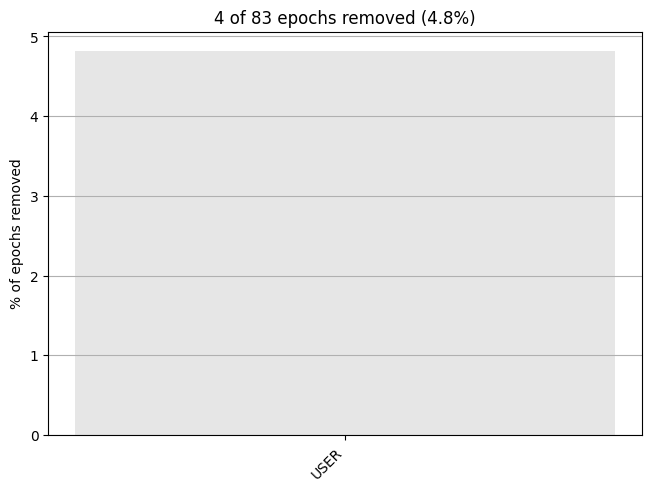

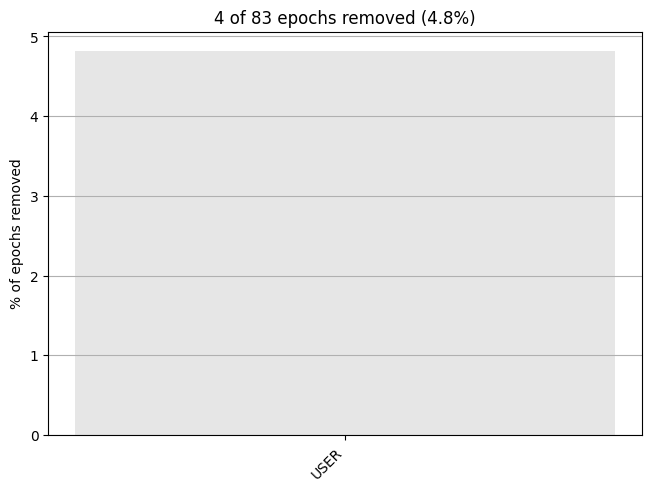

In [37]:
## Reject bad trials using condition-specific baseline windows
# We compute peak-to-peak (PTP) amplitude within the baseline and ERP windows for each condition
# and drop epochs exceeding a threshold, while reporting offending channels per epoch.

amp_thresh = 500e-6  # 500 µV
# Baseline and ERP windows (seconds, relative to event onset)
baseline_window = [-1, -0.65]
erp_window = [0.1, 0.65]

# Channels to ignore when deciding to drop epochs
# These channels are excluded from the rejection decision but are reported separately if offending.
ignored_channels = ["T7", "Pz"]  # set to [] to disable

# Helper to extract movement type from label (if present)
def _movement_from_label(label: str) -> str:
    if not isinstance(label, str):
        return 'other'
    parts = label.lower().split('/')
    return parts[-1] if parts else 'other'

# Map each epoch to its condition label and movement type
inv_event_id = {v: k for k, v in epochs.event_id.items()}
labels = [inv_event_id.get(code, str(code)) for code in epochs.events[:, 2]]
movements = [_movement_from_label(lb) for lb in labels]

X = epochs.get_data()  # shape (n_epochs, n_channels, n_times)
ch_names = epochs.ch_names

# Resolve ignored channel indices (case-insensitive)
upper_map = {ch.upper(): i for i, ch in enumerate(ch_names)}
ignored_idx = [upper_map[c.upper()] for c in ignored_channels if c.upper() in upper_map]

# Index ranges for baseline and ERP windows
tmin, tmax = baseline_window
i0b, i1b = epochs.time_as_index([tmin, tmax])
i0b, i1b = (i0b, i1b) if i0b <= i1b else (i1b, i0b)

# ERP window
te0, te1 = erp_window
i0e, i1e = epochs.time_as_index([te0, te1])
i0e, i1e = (i0e, i1e) if i0e <= i1e else (i1e, i0e)

# Peak-to-peak per channel in each window
ptp_baseline = np.ptp(X[:, :, i0b:i1b + 1], axis=2)  # (n_epochs, n_channels)
ptp_erp = np.ptp(X[:, :, i0e:i1e + 1], axis=2)       # (n_epochs, n_channels)

# Build masks excluding ignored channels for decision
n_epochs, n_channels = ptp_baseline.shape
all_ch_idx = np.arange(n_channels)
consider_idx_mask = np.ones(n_channels, dtype=bool)
if ignored_idx:
    consider_idx_mask[ignored_idx] = False

# Epoch-level bad masks (any non-ignored channel exceeds threshold)
bad_baseline = (ptp_baseline[:, consider_idx_mask] > amp_thresh).any(axis=1)
bad_erp = (ptp_erp[:, consider_idx_mask] > amp_thresh).any(axis=1)

# Combine rejection criteria (bad in either window)
bad_mask = bad_baseline | bad_erp
bad_indices = np.flatnonzero(bad_mask).tolist()

# Summaries
n_bad_baseline = int(bad_baseline.sum())
n_bad_erp = int(bad_erp.sum())
n_bad_total = len(bad_indices)

print(f"Rejection summary (threshold: {amp_thresh*1e6:.0f} µV):")
print(f"- Bad in baseline window {baseline_window}: {n_bad_baseline}")
print(f"- Bad in ERP window {erp_window}: {n_bad_erp}")
print(f"- Total to drop: {n_bad_total} of {len(epochs)}")
if ignored_idx:
    print(f"- Ignored channels (excluded from decision): {', '.join([ch_names[i] for i in ignored_idx])}")

# Report offending channels per rejected epoch
if bad_indices:
    print("\nDetail of offending channels per rejected epoch:")
    for idx in bad_indices:
        # Offending channels per window
        ch_bad_baseline_idx_all = np.flatnonzero(ptp_baseline[idx] > amp_thresh)
        ch_bad_erp_idx_all = np.flatnonzero(ptp_erp[idx] > amp_thresh)

        # Split into considered vs ignored offenders
        ch_bad_baseline_idx_considered = [i for i in ch_bad_baseline_idx_all if consider_idx_mask[i]]
        ch_bad_erp_idx_considered = [i for i in ch_bad_erp_idx_all if consider_idx_mask[i]]
        ch_bad_baseline_idx_ignored = [i for i in ch_bad_baseline_idx_all if not consider_idx_mask[i]]
        ch_bad_erp_idx_ignored = [i for i in ch_bad_erp_idx_all if not consider_idx_mask[i]]

        ch_bad_baseline = [ch_names[i] for i in ch_bad_baseline_idx_considered]
        ch_bad_erp = [ch_names[i] for i in ch_bad_erp_idx_considered]
        ch_ignored_baseline = [ch_names[i] for i in ch_bad_baseline_idx_ignored]
        ch_ignored_erp = [ch_names[i] for i in ch_bad_erp_idx_ignored]

        label = labels[idx] if idx < len(labels) else "unknown"
        move = movements[idx] if idx < len(movements) else "unknown"

        # Format message
        msg = [
            f"Epoch {idx}: label={label}, movement={move}",
            f"  - Baseline {baseline_window} bad channels ({len(ch_bad_baseline)}): {', '.join(ch_bad_baseline) if ch_bad_baseline else 'None'}",
            # f"  - Baseline {baseline_window} offending but ignored ({len(ch_ignored_baseline)}): {', '.join(ch_ignored_baseline) if ch_ignored_baseline else 'None'}",
            f"  - ERP {erp_window} bad channels ({len(ch_bad_erp)}): {', '.join(ch_bad_erp) if ch_bad_erp else 'None'}",
            # f"  - ERP {erp_window} offending but ignored ({len(ch_ignored_erp)}): {', '.join(ch_ignored_erp) if ch_ignored_erp else 'None'}",
        ]
        print("\n".join(msg))

# Drop bad epochs and visualize drop log
epochs.drop(bad_indices)
epochs.plot_drop_log()


##### Subtract Baseline Mean from Each Epoch

Subtract the baseline mean from each epoch, subject to baseline window: -1 to -0.7.

Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


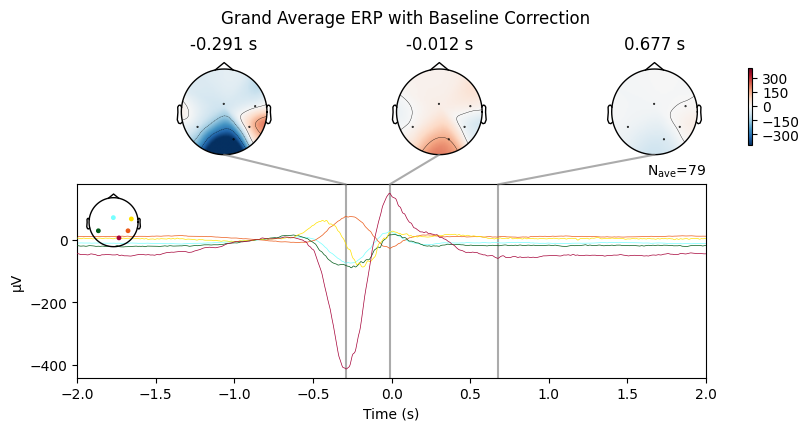

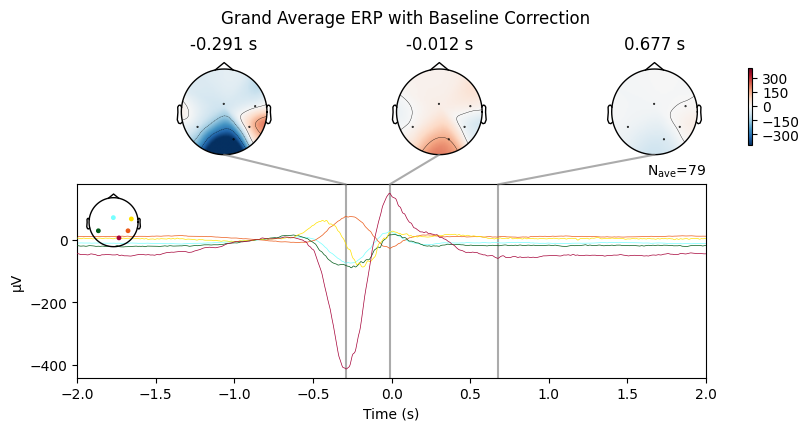

In [38]:
baseline_window = [-1, -0.7]

epochs.average().apply_baseline(baseline=baseline_window).plot_joint(picks=['Cz','T8','P7','P8','O2'], title='Grand Average ERP with Baseline Correction')

Not setting metadata
79 matching events found
No baseline correction applied
0 projection items activated


combining channels using "mean"


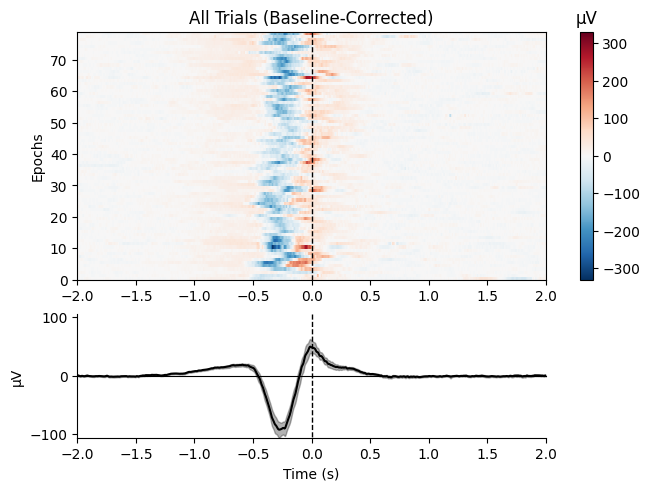

[<Figure size 640x480 with 3 Axes>]

In [39]:
epochs.plot_image(combine="mean", sigma=0, title='All Trials (Baseline-Corrected)', picks=['Cz','T8','P7','P8','O2'])

In [40]:
## Save baseline-corrected epoched EEG data to file
filename = data_dir + f"eeg_exp{n_experiment}_epochs_1_reref_baseline-epo.fif"
epochs.save(filename, overwrite=True)

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.


[WindowsPath('c:/Users/doubl/Desktop/School/Capstone/FYDP-rename_later-/poc/eeg_analysis/experiment_data/exp3/eeg_exp3_epochs_1_reref_baseline-epo.fif')]

No projector specified for this dataset. Please consider the method self.add_proj.


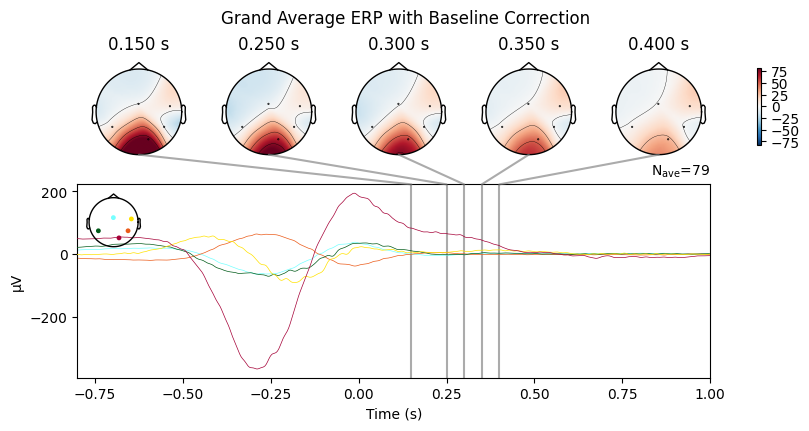

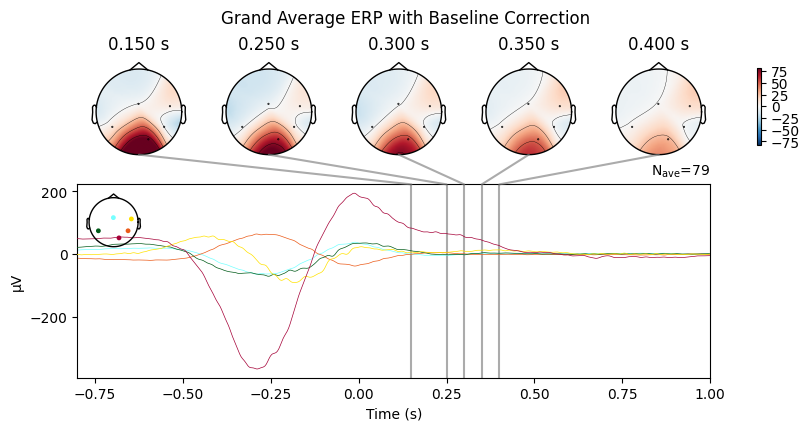

In [41]:
epochs_cropped = epochs.copy().crop(tmin=-0.8, tmax=1)
epochs_cropped.average().plot_joint(picks=['Cz','T8','P7','P8','O2'], title='Grand Average ERP with Baseline Correction', times=[0.15, 0.25, 0.3, 0.35, 0.4])

## ERP Results/Analysis

Visualize and calculate the ERP results across trials.

This should allow for visualization of specific eye movement types and targets, averaging or selecting specific trials as necessary.

We also want to analyze N250 (T7,T8, P7,P8, O1,O2) and P300 (Pz,Cz) in particular. The plots will show a shaded region that is considered when averaging to find these components, and the scripts should print out the associated voltage level (Mean +/- SD)

##### Imports and Data Loading

In [42]:
import mne
from typing import Union, Sequence, Dict, Any
import numpy as np
import matplotlib.pyplot as plt

In [43]:
# Set experiment number and data directory
n_experiment = 3
data_dir = f'experiment_data/exp{n_experiment}/'

In [44]:
## Load epoch data
filename = data_dir + f"eeg_exp{n_experiment}_epochs_1_reref_baseline-epo.fif"
epochs = mne.read_epochs(filename, preload=True)

Reading c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\experiment_data\exp3\eeg_exp3_epochs_1_reref_baseline-epo.fif ...
    Found the data of interest:
        t =   -2000.00 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
79 matching events found
No baseline correction applied
0 projection items activated


### Plotting Function

In [45]:
# Plot params
error_region_alpha = 0.2 # transparency for shaded error region
individual_trial_alpha = 0.4 # transparency for individual trials in grand plot

In [46]:
## Familiar vs Unfamiliar ERP plotter
def plot_familiar_vs_unfamiliar(
    epochs: mne.Epochs,
    component: str = "N250",
    familiar_selector: Union[None, str, Sequence[Union[str, int, bool]]] = None,
    unfamiliar_selector: Union[None, str, Sequence[Union[str, int, bool]]] = None,
    picks: Union[None, Sequence[str]] = None,
    time_window: tuple = (0, 0.6),
    analysis_window: tuple = None,
    average: bool = True,
    avg_method: str = "mean",  # 'mean' or 'median'
    smooth_ms: Union[None, float, int] = None,  # moving-average window (ms)
    title: Union[None, str] = None,
) -> tuple:
    """Plot familiar vs unfamiliar ERP components with optional averaging and smoothing."""
    
    # Validate inputs
    component = component.upper()
    if component not in {"N250", "P300"}:
        raise ValueError("component must be 'N250' or 'P300'")
    if avg_method.lower() not in {"mean", "median"}:
        raise ValueError("avg_method must be 'mean' or 'median'")

    # Component-specific parameters
    component_params = {
        "N250": {"peak_time": 0.250, "default_picks": ["T7", "T8", "P7", "P8", "O2"]},
        "P300": {"peak_time": 0.300, "default_picks": ["Pz", "Cz"]}
    }
    
    if not analysis_window:
        peak_time = component_params[component]["peak_time"]
        analysis_window = (peak_time - 0.050, peak_time + 0.050)
    else:
        peak_time = (analysis_window[0] + analysis_window[1]) / 2.0
    
    default_picks = component_params[component]["default_picks"]
    
    # Resolve channel picks
    def _resolve_picks(channel_candidates):
        """Convert channel names to available channels in epochs."""
        channel_map = {ch.upper(): ch for ch in epochs.ch_names}
        resolved = [channel_map[c.upper()] for c in channel_candidates if c.upper() in channel_map]
        if not resolved:
            raise RuntimeError(f"No requested channels found. Tried {channel_candidates}. Available: {epochs.ch_names}")
        return resolved

    picks = _resolve_picks(default_picks if picks is None else picks)

    # Get epoch labels
    event_id_to_label = {v: k for k, v in epochs.event_id.items()}
    epoch_labels = [event_id_to_label.get(code, str(code)) for code in epochs.events[:, 2]]

    def _get_epoch_indices(selector, auto_mask=None):
        """Get epoch indices based on selector and auto_mask."""
        n_epochs = len(epochs)
        
        # Use auto_mask if no selector provided
        if selector is None:
            return np.flatnonzero(auto_mask) if auto_mask is not None else np.arange(n_epochs)
        
        # Boolean mask
        if (isinstance(selector, (list, np.ndarray)) and len(selector) == n_epochs 
            and all(isinstance(x, (bool, np.bool_)) for x in selector)):
            return np.flatnonzero(selector)
        
        # Integer indices
        if (isinstance(selector, (list, np.ndarray)) and len(selector) > 0 
            and all(isinstance(x, (int, np.integer)) for x in selector)):
            indices = np.asarray(selector, dtype=int)
            if indices.min() < 0 or indices.max() >= n_epochs:
                raise IndexError("Selector indices out of range")
            return np.unique(indices)
        
        # String matching
        def _matches_label(search_string):
            search_string = search_string.lower()
            return np.array([search_string in str(label).lower() for label in epoch_labels], dtype=bool)
        
        if isinstance(selector, str):
            return np.flatnonzero(_matches_label(selector))
        
        if isinstance(selector, (list, tuple)) and all(isinstance(x, str) for x in selector):
            mask = np.zeros(n_epochs, dtype=bool)
            for s in selector:
                mask |= _matches_label(s)
            return np.flatnonzero(mask)
        
        raise TypeError("Unsupported selector type")

    # Auto-detect familiar/unfamiliar epochs
    # Labels are now 'Fam', 'Unf', or 'Mov'
    auto_familiar = np.array([str(label).lower() == "fam" for label in epoch_labels])
    auto_unfamiliar = np.array([str(label).lower() == "unf" for label in epoch_labels])

    familiar_indices = _get_epoch_indices(familiar_selector, auto_familiar)
    unfamiliar_indices = _get_epoch_indices(unfamiliar_selector, auto_unfamiliar)
    
    if familiar_indices.size == 0:
        raise ValueError("No familiar epochs selected")
    if unfamiliar_indices.size == 0:
        raise ValueError("No unfamiliar epochs selected")

    # Extract and prepare data
    tmin, tmax = time_window
    familiar_epochs = epochs[familiar_indices].copy().pick(picks=picks).crop(tmin=tmin, tmax=tmax)
    unfamiliar_epochs = epochs[unfamiliar_indices].copy().pick(picks=picks).crop(tmin=tmin, tmax=tmax)

    sfreq = float(familiar_epochs.info.get('sfreq', epochs.info.get('sfreq', 1.0)))

    def _smooth_data(data: np.ndarray, window_size: int) -> np.ndarray:
        """Apply moving average smoothing to data."""
        if window_size <= 1:
            return data
        
        kernel = np.ones(window_size, dtype=float) / window_size
        
        if data.ndim == 1:
            return np.convolve(data, kernel, mode='same')
        
        return np.apply_along_axis(lambda x: np.convolve(x, kernel, mode='same'), 
                                 axis=1, arr=data)

    # Calculate smoothing window
    smooth_window = 0
    if smooth_ms is not None:
        smooth_window = int(round(float(smooth_ms) * sfreq / 1000.0))
        if smooth_window < 1:
            smooth_window = 0
        # Prefer odd window size for symmetric smoothing
        if smooth_window % 2 == 0 and smooth_window > 1:
            smooth_window += 1

    # Get data (mean across channels)
    familiar_data = familiar_epochs.get_data().mean(axis=1)  # (n_familiar, n_times)
    unfamiliar_data = unfamiliar_epochs.get_data().mean(axis=1)  # (n_unfamiliar, n_times)
    
    times = familiar_epochs.times

    # Create plot
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # Plot individual trials or averages
    if not average:
        # Apply smoothing to individual trials if requested
        if smooth_window > 1:
            familiar_data_smoothed = _smooth_data(familiar_data, smooth_window)
            unfamiliar_data_smoothed = _smooth_data(unfamiliar_data, smooth_window)
        else:
            familiar_data_smoothed = familiar_data
            unfamiliar_data_smoothed = unfamiliar_data
            
        # Plot individual trials
        for trial in familiar_data_smoothed:
            ax.plot(times, trial * 1e6, color="#1f77b4", alpha=individual_trial_alpha, linewidth=0.8)
        for trial in unfamiliar_data_smoothed:
            ax.plot(times, trial * 1e6, color="#d62728", alpha=individual_trial_alpha, linewidth=0.8)
        
        # Calculate averages for the lines
        familiar_avg = familiar_data_smoothed.mean(axis=0)
        unfamiliar_avg = unfamiliar_data_smoothed.mean(axis=0)
        
        familiar_label = "Familiar"
        unfamiliar_label = "Unfamiliar"
    else:  
        # Apply smoothing to all trials first
        if smooth_window > 1:
            familiar_data_smoothed = _smooth_data(familiar_data, smooth_window)
            unfamiliar_data_smoothed = _smooth_data(unfamiliar_data, smooth_window)
        else:
            familiar_data_smoothed = familiar_data
            unfamiliar_data_smoothed = unfamiliar_data
        
        # For median averaging, smooth the median waveform instead of individual trials
        if avg_method.lower() == 'median':
            familiar_median = np.median(familiar_data, axis=0)
            unfamiliar_median = np.median(unfamiliar_data, axis=0)
            
            if smooth_window > 1:
                familiar_avg = _smooth_data(familiar_median, smooth_window)
                unfamiliar_avg = _smooth_data(unfamiliar_median, smooth_window)
            else:
                familiar_avg = familiar_median
                unfamiliar_avg = unfamiliar_median
            
            # Calculate standard error from smoothed median data
            familiar_sem = familiar_data_smoothed.std(axis=0) / np.sqrt(len(familiar_data_smoothed))
            unfamiliar_sem = unfamiliar_data_smoothed.std(axis=0) / np.sqrt(len(unfamiliar_data_smoothed))
        else:
            familiar_avg = familiar_data_smoothed.mean(axis=0)
            unfamiliar_avg = unfamiliar_data_smoothed.mean(axis=0)
            
            # Calculate standard error from smoothed data for error bars
            familiar_sem = familiar_data_smoothed.std(axis=0) / np.sqrt(len(familiar_data_smoothed))
            unfamiliar_sem = unfamiliar_data_smoothed.std(axis=0) / np.sqrt(len(unfamiliar_data_smoothed))
        
        # Add shaded error bars based on smoothed data
        ax.fill_between(times, 
                       (familiar_avg - familiar_sem) * 1e6, 
                       (familiar_avg + familiar_sem) * 1e6, 
                       color="#1f77b4", alpha=error_region_alpha)
        ax.fill_between(times, 
                       (unfamiliar_avg - unfamiliar_sem) * 1e6, 
                       (unfamiliar_avg + unfamiliar_sem) * 1e6, 
                       color="#d62728", alpha=error_region_alpha)

        familiar_label = f"Familiar ({avg_method})"
        unfamiliar_label = f"Unfamiliar ({avg_method})"

    # Plot average lines
    ax.plot(times, familiar_avg * 1e6, color="#1f77b4", linewidth=2.0, label=familiar_label)
    ax.plot(times, unfamiliar_avg * 1e6, color="#d62728", linewidth=2.0, label=unfamiliar_label)

    # Add component markers
    ax.axvline(peak_time, color="k", linestyle="--", linewidth=1.2, 
               label=f"{component} ({int(peak_time*1000)} ms)")
    ax.axvspan(analysis_window[0], analysis_window[1], color="k", alpha=0.10)

    # Format plot
    ax.set_xlim(tmin, tmax)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    
    if title:
        ax.set_title(title)
    else:
        ax.set_title(f"{component} Familiarity ERP ({', '.join(picks)})")
        
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.2)

    # Calculate statistics in analysis window (unsmoothed data)
    in_window_mask = (times >= analysis_window[0]) & (times <= analysis_window[1])
        
    familiar_values = familiar_data[:, in_window_mask].mean(axis=1) * 1e6
    unfamiliar_values = unfamiliar_data[:, in_window_mask].mean(axis=1) * 1e6

    stats = {
        "component": component,
        "avg_method": avg_method.lower(),
        "smooth_ms": float(smooth_ms) if smooth_ms is not None else None,
        "window_s": list(analysis_window),
        "channels": list(picks),
        "Familiar": {
            "n": int(familiar_data.shape[0]), 
            "mean_uV": float(np.mean(familiar_values)), 
            "sd_uV": float(np.std(familiar_values, ddof=1)) if familiar_values.size > 1 else float("nan")
        },
        "Unfamiliar": {
            "n": int(unfamiliar_data.shape[0]), 
            "mean_uV": float(np.mean(unfamiliar_values)), 
            "sd_uV": float(np.std(unfamiliar_values, ddof=1)) if unfamiliar_values.size > 1 else float("nan")
        },
    }

    # Print summary
    print(f"{component} analysis:")
    print(f"  Window: {analysis_window[0]:.3f}-{analysis_window[1]:.3f}s")
    print(f"  Channels: {picks}")
    print(f"  Method: {stats['avg_method']}, Smoothing: {stats['smooth_ms']}ms")
    print(f"  Familiar: n={stats['Familiar']['n']}, mean={stats['Familiar']['mean_uV']:.2f} µV, "
          f"sd={stats['Familiar']['sd_uV']:.2f} µV" if familiar_values.size > 1 else "NA")
    print(f"  Unfamiliar: n={stats['Unfamiliar']['n']}, mean={stats['Unfamiliar']['mean_uV']:.2f} µV, "
          f"sd={stats['Unfamiliar']['sd_uV']:.2f} µV" if unfamiliar_values.size > 1 else "NA")

    plt.show()
    return fig, stats

In [47]:
_base_epochs = epochs  # Use previously loaded epochs

### Plot N250 

#### Parieto-occipital channels averaged (N250, fusiform)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['T8', 'P7', 'P8', 'O2']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=38, mean=14.67 µV, sd=20.85 µV
  Unfamiliar: n=38, mean=23.05 µV, sd=18.45 µV


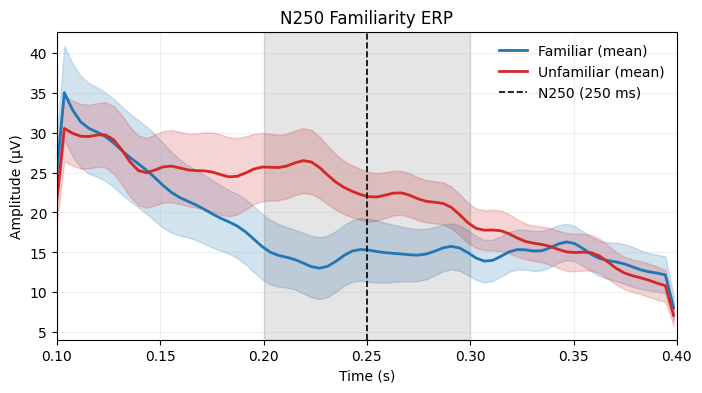

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.2, 0.3], 'channels': ['T8', 'P7', 'P8', 'O2'], 'Familiar': {'n': 38, 'mean_uV': 14.670069321990274, 'sd_uV': 20.854196956955487}, 'Unfamiliar': {'n': 38, 'mean_uV': 23.04671310762373, 'sd_uV': 18.4538267079368}}


In [52]:
## Plot N250 familiar vs unfamiliar (averaged across parieto-occipital channels, all valid trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="N250",
    picks=["T8", "P7", "P8", "O2"],
    time_window=(0.1, 0.4),
    average=True,
    avg_method="mean",
    smooth_ms=10,
    title="N250 Familiarity ERP",
)
print(stats)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['T8', 'P7', 'P8', 'O2']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=38, mean=14.67 µV, sd=20.85 µV
  Unfamiliar: n=38, mean=23.05 µV, sd=18.45 µV


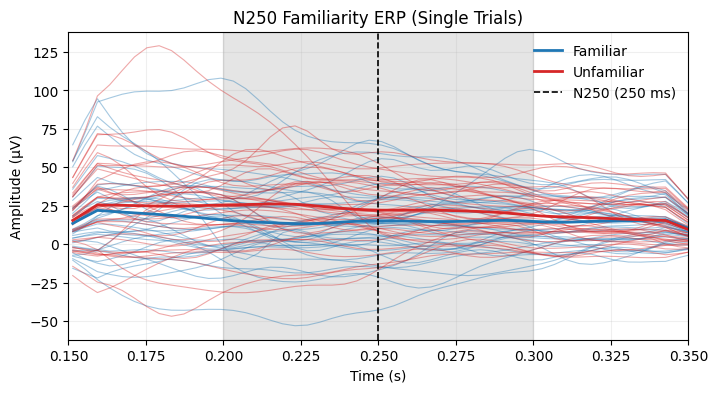

In [53]:
## N250 (single trials overlay)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="N250",
    picks=["T8", "P7", "P8", "O2"],
    time_window=(0.15, 0.35),
    average=False,
    smooth_ms=20,
    avg_method="mean",
    title="N250 Familiarity ERP (Single Trials)",
)

#### T8 (aka T6) only

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['T8']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=38, mean=5.16 µV, sd=21.27 µV
  Unfamiliar: n=38, mean=7.85 µV, sd=14.78 µV


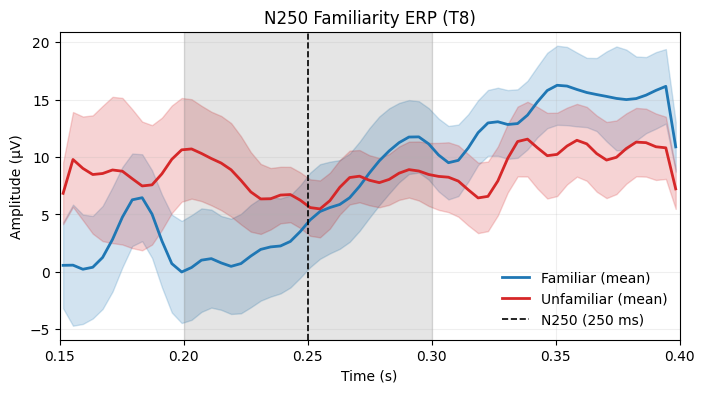

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.2, 0.3], 'channels': ['T8'], 'Familiar': {'n': 38, 'mean_uV': 5.157749307181877, 'sd_uV': 21.268605310841036}, 'Unfamiliar': {'n': 38, 'mean_uV': 7.852784836618741, 'sd_uV': 14.776042961354563}}


In [54]:
## Plot N250 familiar vs unfamiliar (averaged T8, all valid trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="N250",
    picks=["T8"],
    time_window=(0.15, 0.4),
    average=True,
    smooth_ms=10,
    avg_method="mean", 
    title="N250 Familiarity ERP (T8)",
)
print(stats)

#### P7 only

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['P7']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=38, mean=-0.06 µV, sd=21.37 µV
  Unfamiliar: n=38, mean=-3.15 µV, sd=20.49 µV


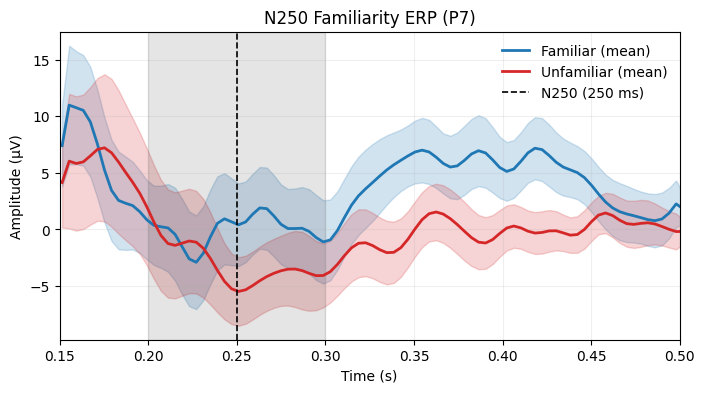

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.2, 0.3], 'channels': ['P7'], 'Familiar': {'n': 38, 'mean_uV': -0.06077918567595325, 'sd_uV': 21.373001563185824}, 'Unfamiliar': {'n': 38, 'mean_uV': -3.1528501587050224, 'sd_uV': 20.48721212563533}}


In [55]:
## Plot N250 familiar vs unfamiliar (averaged P7, all valid trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="N250",
    picks=["P7"],
    time_window=(0.15, 0.5),
    average=True,
    smooth_ms=10,
    avg_method="mean", 
    title="N250 Familiarity ERP (P7)",
)
print(stats)

#### P8 only

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['P8']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=38, mean=2.54 µV, sd=15.29 µV
  Unfamiliar: n=38, mean=5.15 µV, sd=17.05 µV


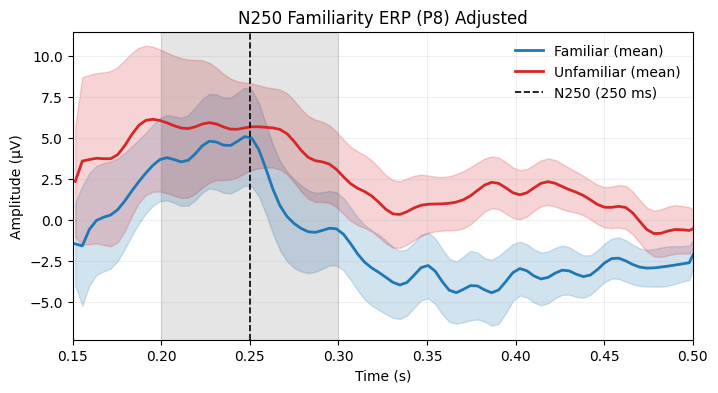

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.2, 0.3], 'channels': ['P8'], 'Familiar': {'n': 38, 'mean_uV': 2.5401377239868332, 'sd_uV': 15.28872353852718}, 'Unfamiliar': {'n': 38, 'mean_uV': 5.145024502399141, 'sd_uV': 17.05415928143727}}


In [56]:
## Plot N250 familiar vs unfamiliar (averaged P8, all valid trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="N250",
    picks=["P8"],
    time_window=(0.15, 0.5),
    average=True,
    smooth_ms=10,
    # analysis_window=(0.25, 0.35), # custom analysis window - delayed peak
    avg_method="mean", 
    title="N250 Familiarity ERP (P8) Adjusted",
)
print(stats)

#### O2 only

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['O2']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=38, mean=51.04 µV, sd=79.02 µV
  Unfamiliar: n=38, mean=82.34 µV, sd=69.71 µV


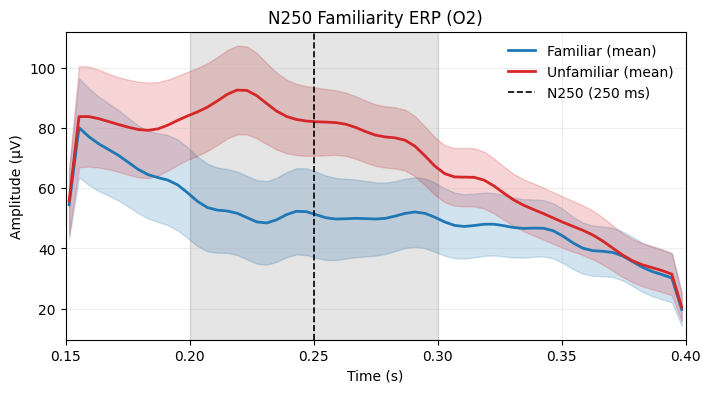

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.2, 0.3], 'channels': ['O2'], 'Familiar': {'n': 38, 'mean_uV': 51.04316944246833, 'sd_uV': 79.02398571222805}, 'Unfamiliar': {'n': 38, 'mean_uV': 82.34189325018205, 'sd_uV': 69.70780855642872}}


In [57]:
## Plot N250 familiar vs unfamiliar (averaged O2, all valid trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="N250",
    picks=["O2"],
    time_window=(0.15, 0.4),
    average=True,
    smooth_ms=10,
    avg_method="mean", 
    title="N250 Familiarity ERP (O2)",
)
print(stats)

### Plot P300

#### Midline channels averaged (P300)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz', 'Cz']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=38, mean=97.61 µV, sd=64.99 µV
  Unfamiliar: n=38, mean=96.33 µV, sd=47.41 µV


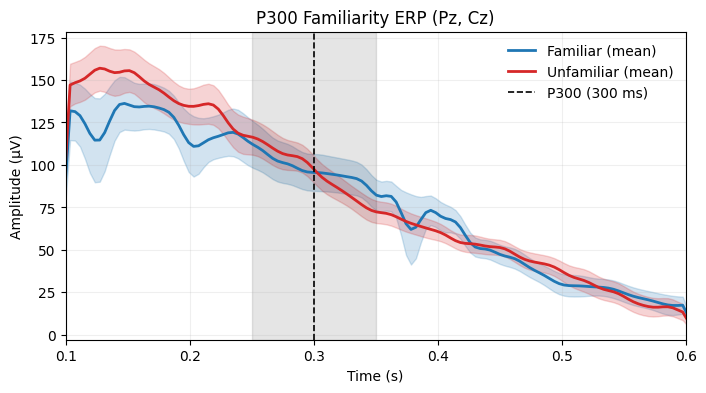

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.25, 0.35], 'channels': ['Pz', 'Cz'], 'Familiar': {'n': 38, 'mean_uV': 97.6127842211221, 'sd_uV': 64.99039937560939}, 'Unfamiliar': {'n': 38, 'mean_uV': 96.32558694729431, 'sd_uV': 47.41288711563361}}


In [58]:
## Plot P300 familiar vs unfamiliar (averaged Pz and Cz, all valid trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="P300",
    picks=["Pz", "Cz"],
    time_window=(0.1, 0.6),
    average=True,
    smooth_ms=10,
    avg_method="mean",
    title="P300 Familiarity ERP (Pz, Cz)",
)
print(stats)

#### Pz Only

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=16, mean=162.32 µV, sd=101.44 µV
  Unfamiliar: n=19, mean=138.76 µV, sd=101.76 µV


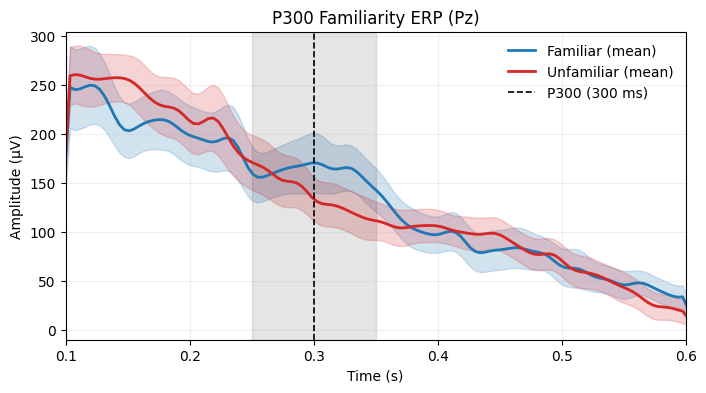

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.25, 0.35], 'channels': ['Pz'], 'Familiar': {'n': 16, 'mean_uV': 162.32407915410363, 'sd_uV': 101.43835555751942}, 'Unfamiliar': {'n': 19, 'mean_uV': 138.7602226910339, 'sd_uV': 101.76121057340566}}


In [97]:
## Plot P300 familiar vs unfamiliar (averaged Pz, all valid trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="P300",
    picks=["Pz"],
    time_window=(0.1, 0.6),
    average=True,
    smooth_ms=10,
    avg_method="mean",
    title="P300 Familiarity ERP (Pz)",
)
print(stats)

#### Cz Only

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Cz']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=38, mean=0.91 µV, sd=13.42 µV
  Unfamiliar: n=38, mean=-2.98 µV, sd=13.10 µV


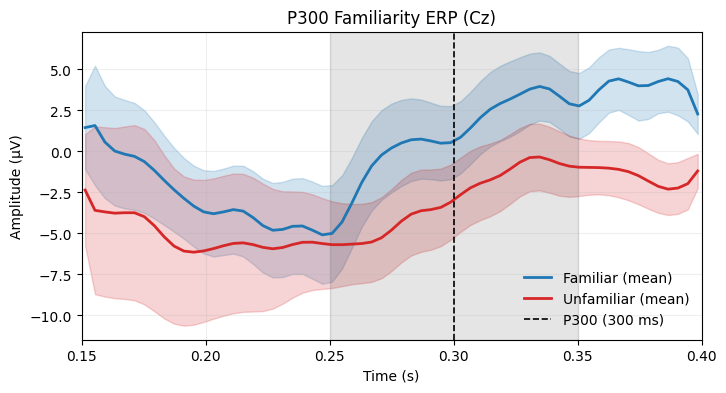

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.25, 0.35], 'channels': ['Cz'], 'Familiar': {'n': 38, 'mean_uV': 0.9148401972979807, 'sd_uV': 13.418347439799172}, 'Unfamiliar': {'n': 38, 'mean_uV': -2.98228427246992, 'sd_uV': 13.097267150135504}}


In [60]:
## Plot P300 familiar vs unfamiliar (averaged Cz, all valid trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="P300",
    picks=["Cz"],
    time_window=(0.15, 0.4),
    average=True,
    smooth_ms=10,
    avg_method="mean",
    title="P300 Familiarity ERP (Cz)",
)
print(stats)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Cz']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=38, mean=0.91 µV, sd=13.42 µV
  Unfamiliar: n=38, mean=-2.98 µV, sd=13.10 µV


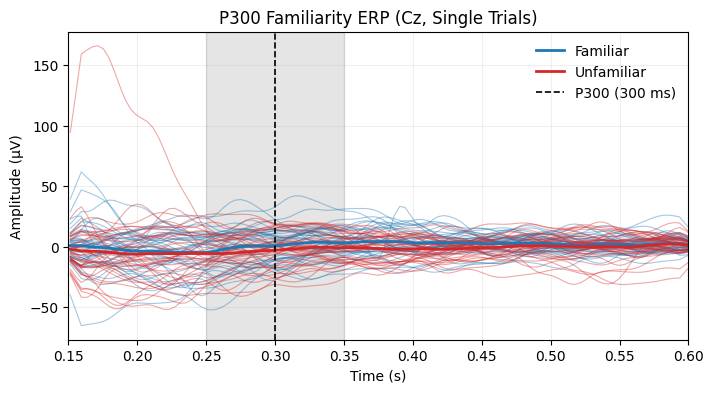

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.25, 0.35], 'channels': ['Cz'], 'Familiar': {'n': 38, 'mean_uV': 0.9148401972979807, 'sd_uV': 13.418347439799172}, 'Unfamiliar': {'n': 38, 'mean_uV': -2.98228427246992, 'sd_uV': 13.097267150135504}}


In [61]:
## P300 single trials overlay (Cz)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="P300",
    picks=["Cz"],
    time_window=(0.15, 0.6),
    average=False,
    smooth_ms=20,
    title="P300 Familiarity ERP (Cz, Single Trials)",
)
print(stats)

# Feature Extraction

Extract statistical features of ERP for specific windows and channels.

Statistical features:
- Mean voltage
- Median voltage
- Max voltage
- Minimum voltage
- Peak-to-peak amplitude
- Standard deviation
- Skewness
- Area under the curve
- Kurtosis


In [62]:
## Imports
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import mne

In [63]:
## Epoch feature extraction function 
def extract_epoch_features(epochs, ch_windows):
    sfreq = float(epochs.info.get('sfreq', 250))

    # Select channels present in epochs
    name_map = {ch.upper(): ch for ch in epochs.ch_names}
    selected = {}
    for ch, win in ch_windows.items():
        if ch.upper() in name_map:
            selected[name_map[ch.upper()]] = win
    if not selected:
        raise RuntimeError(f"None of target channels {list(ch_windows.keys())} found in epochs: {epochs.ch_names}")

    X = epochs.get_data()  # (n_epochs, n_channels, n_times)
    ch_idx = {ch: epochs.ch_names.index(ch) for ch in selected.keys()}

    # Epoch condition labels from event IDs
    id_map = {v: k for k, v in epochs.event_id.items()}
    conditions = [id_map.get(code, str(code)) for code in epochs.events[:, 2]]

    # Pre-compute sample index ranges per channel window
    idx_windows = {}
    for ch, (t0, t1) in selected.items():
        i0, i1 = epochs.time_as_index([float(t0), float(t1)])
        if i0 > i1:  # Flip if reversed
            i0, i1 = i1, i0
        idx_windows[ch] = (int(i0), int(i1))

    stat_order = ['mean', 'median', 'max', 'min', 'ptp', 'std', 'skew', 'auc', 'kurtosis']

    # Define N250 and P300 channel groups
    n250_channels = ['T7', 'T8', 'P7', 'P8', 'O1', 'O2']
    p300_channels = ['Cz', 'Pz']
    
    # Identify present channels for each group
    n250_present = [ch for ch in n250_channels if ch in selected.keys()]
    p300_present = [ch for ch in p300_channels if ch in selected.keys()]

    rows = []
    for epoch in range(X.shape[0]):
        row = {}
        for ch, (i0, i1) in idx_windows.items():
            x = X[epoch, ch_idx[ch], i0:i1 + 1] * 1e6  # convert to µV
            if x.size == 0:
                vals = {s: float('nan') for s in stat_order}
            else:
                vals = {
                    'mean': float(np.mean(x)),
                    'median': float(np.median(x)),
                    'max': float(np.max(x)),
                    'min': float(np.min(x)),
                    'ptp': float(np.ptp(x)),
                    'std': float(np.std(x, ddof=0)),
                    'skew': float(skew(x, bias=False)) if x.size > 2 else float('nan'),
                    'auc': float(np.trapezoid(x, dx=1.0 / sfreq)),  # integrate using trapezoidal rule
                    'kurtosis': float(kurtosis(x, fisher=False, bias=False)) if x.size > 3 else float('nan'),
                }
            for s in stat_order:
                row[f"{ch}_{s}"] = vals[s]
        
        # Compute averaged features for N250
        if n250_present:
            for s in stat_order:
                values = [row[f"{ch}_{s}"] for ch in n250_present if f"{ch}_{s}" in row]
                if values:
                    row[f"N250_avg_{s}"] = float(np.nanmean(values))
                else:
                    row[f"N250_avg_{s}"] = float('nan')
        
        # Compute averaged features for P300
        if p300_present:
            for s in stat_order:
                values = [row[f"{ch}_{s}"] for ch in p300_present if f"{ch}_{s}" in row]
                if values:
                    row[f"P300_avg_{s}"] = float(np.nanmean(values))
                else:
                    row[f"P300_avg_{s}"] = float('nan')
        
        row['condition'] = conditions[epoch] if epoch < len(conditions) else None
        rows.append(row)

    df = pd.DataFrame(rows)

    # Order columns by channel then stat, condition first
    preferred_ch_order = ['Cz','Pz','T7','T8', 'P7', 'P8', 'O1','O2']
    present = [ch for ch in preferred_ch_order if ch in selected.keys()] + [ch for ch in selected.keys() if ch not in preferred_ch_order]
    ordered_cols = []
    for ch in present:
        ordered_cols.extend([f"{ch}_{s}" for s in stat_order])
    
    # Add averaged N250 and P300 columns
    if n250_present:
        ordered_cols.extend([f"N250_avg_{s}" for s in stat_order])
    if p300_present:
        ordered_cols.extend([f"P300_avg_{s}" for s in stat_order])

    cols = ['condition'] + [c for c in ordered_cols if c in df.columns]
    df = df[cols]
    return df

In [64]:
# Set experiment number and data directory
n_experiment = 3
data_dir = f'experiment_data/exp{n_experiment}/'

In [65]:
## Load epoch data
filename = data_dir + f"eeg_exp{n_experiment}_epochs_1_reref_baseline-epo.fif"
epochs = mne.read_epochs(filename, preload=True)

Reading c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\experiment_data\exp3\eeg_exp3_epochs_1_reref_baseline-epo.fif ...
    Found the data of interest:
        t =   -2000.00 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
79 matching events found
No baseline correction applied
0 projection items activated


In [66]:
## Define windows for N250 and P300
win_n250 = (0.2, 0.3) # T8, P7, O2
win_n250_late = (0.25, 0.35) # P8
win_p300 = (0.25, 0.35) # Cz

In [67]:
## Run feature extraction

# Channel window mapping
ch_windows = {
    'Cz': win_p300,
    'T8': win_n250,
    'P7': win_n250,
    'P8': win_n250_late,
    'O2': win_n250,
}

features_df = extract_epoch_features(epochs, ch_windows)
print(features_df.shape)
features_df.head(10)

(79, 64)


,condition,Cz_mean,Cz_median,Cz_max,Cz_min,Cz_ptp,Cz_std,Cz_skew,Cz_auc,Cz_kurtosis,...,N250_avg_kurtosis,P300_avg_mean,P300_avg_median,P300_avg_max,P300_avg_min,P300_avg_ptp,P300_avg_std,P300_avg_skew,P300_avg_auc,P300_avg_kurtosis
0,Mov,6.104712,6.114994,12.590617,-0.959081,13.549698,3.443290,-0.130124,0.600006,2.804030,...,2.797784,6.104712,6.114994,12.590617,-0.959081,13.549698,3.443290,-0.130124,0.600006,2.804030
1,Mov,7.461193,6.800499,18.997232,-0.295772,19.293004,4.325046,0.582837,0.727120,3.864454,...,2.960395,7.461193,6.800499,18.997232,-0.295772,19.293004,4.325046,0.582837,0.727120,3.864454
2,Mov,-1.091678,-1.616027,7.635280,-8.125800,15.761080,3.920355,0.420313,-0.122149,2.858467,...,2.697993,-1.091678,-1.616027,7.635280,-8.125800,15.761080,3.920355,0.420313,-0.122149,2.858467
3,Fam,-17.010920,-15.725029,-10.681747,-30.338906,19.657159,5.075956,-1.152427,-1.671854,3.783341,...,3.282067,-17.010920,-15.725029,-10.681747,-30.338906,19.657159,5.075956,-1.152427,-1.671854,3.783341
4,Unf,-0.872291,-2.654858,15.171267,-13.495091,28.666359,7.961080,0.227932,-0.093854,1.960919,...,2.110011,-0.872291,-2.654858,15.171267,-13.495091,28.666359,7.961080,0.227932,-0.093854,1.960919
5,Fam,2.773336,3.275493,6.743870,-1.920382,8.664253,2.419836,-0.275789,0.278148,1.999819,...,2.817995,2.773336,3.275493,6.743870,-1.920382,8.664253,2.419836,-0.275789,0.278148,1.999819
6,Unf,9.436099,15.041365,20.332314,-16.588980,36.921294,11.727383,-1.091657,0.987352,2.729342,...,2.335161,9.436099,15.041365,20.332314,-16.588980,36.921294,11.727383,-1.091657,0.987352,2.729342
7,Fam,-2.701357,-0.572594,22.601012,-26.880467,49.481479,15.604066,-0.022512,-0.288961,1.948767,...,2.313673,-2.701357,-0.572594,22.601012,-26.880467,49.481479,15.604066,-0.022512,-0.288961,1.948767
8,Unf,-17.941205,-17.287394,-5.080333,-33.765289,28.684956,8.074383,-0.396907,-1.762202,2.587207,...,2.784763,-17.941205,-17.287394,-5.080333,-33.765289,28.684956,8.074383,-0.396907,-1.762202,2.587207
9,Fam,15.224260,15.559815,21.252457,8.128553,13.123905,3.570111,-0.410620,1.523675,2.407815,...,3.639691,15.224260,15.559815,21.252457,8.128553,13.123905,3.570111,-0.410620,1.523675,2.407815


In [68]:
## Save features to CSV
out_dir = data_dir if 'data_dir' in globals() else f'experiment_data/exp{n_experiment}/'
out_path = out_dir + f'erp_exp{n_experiment}_features.csv'
features_df.to_csv(out_path, index=False)
print(f"Saved features to {out_path}")

Saved features to experiment_data/exp3/erp_exp3_features.csv
